In [ ]:
!wget https://www.dropbox.com/s/cxyfm60o0n89ubw/Dataset.zip?dl=0
!unzip Dataset.zip?dl=0

--2026-03-19 23:25:07--  https://www.dropbox.com/s/cxyfm60o0n89ubw/Dataset.zip?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.65.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.65.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/8q9ohc07te8tsgqynj0vb/Dataset.zip?rlkey=wrbgcgk1q343qjj7iqjpiebc0&dl=0 [following]
--2026-03-19 23:25:08--  https://www.dropbox.com/scl/fi/8q9ohc07te8tsgqynj0vb/Dataset.zip?rlkey=wrbgcgk1q343qjj7iqjpiebc0&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc2d2dd4ed959cb6b8970998a272.dl.dropboxusercontent.com/cd/0/inline/C8_af6m39vpCY6E8f8Ci-Bp4UhFGTXThGVLJBkY3-JvnL-9dVgSyxyzYwmNBX9IE1fesCTsbwV3hU3dt_kNRkJS4rFzavpWedHAP45RANH8hoiPcqSh585OwSE9eJtb89aWvz-4MS4W3Eo8QzJUxWfOd/file# [following]
--2026-03-19 23:25:08--  https://uc2d2dd4ed959cb6b8970998a272.dl.dropboxusercontent.co

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


import keras

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg19 import VGG19, preprocess_input, decode_predictions

In [ ]:
len(os.listdir("/content/training_dataset/train"))

15

In [ ]:
train_datagen = ImageDataGenerator(zoom_range= 0.5, shear_range= 0.3, horizontal_flip= True, preprocessing_function= preprocess_input )

val_datagen = ImageDataGenerator(preprocessing_function= preprocess_input )

In [ ]:
train = train_datagen.flow_from_directory(directory= "/content/training_dataset/train",
                                          target_size= (256,256), batch_size=32)

val = val_datagen.flow_from_directory(directory= "/content/training_dataset/val",
                                        target_size= (256,256), class_mode='categorical', batch_size=32)

Found 13999 images belonging to 15 classes.
Found 4662 images belonging to 15 classes.


In [ ]:
t_img , label = next(train)

In [ ]:
def plotImage(img_arr, label):

    for im , l in zip(img_arr , label):
        plt.figure(figsize=(5,5))
        plt.show()


In [ ]:
plotImage(t_img[:3], label[:3])

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels
val.reset()
y_true = val.classes

# Predict
y_pred_prob = model.predict(val, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Class labels
labels = list(train.class_indices.keys())

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=labels))


Create Model

In [ ]:
from keras.layers import Dense, Flatten
from keras.models import Model
from keras.applications.vgg19 import VGG19
from keras.applications.resnet import ResNet101
import keras

In [ ]:
base_model = ResNet101(input_shape=(256,256,3), include_top=False)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
base_model.summary()

In [ ]:
X = Flatten()(base_model.output)

X = Dense(units= 15, activation='softmax')(X)


#Creating our model
model = Model(base_model.input, X)

In [ ]:
model.summary()

Model: "model"

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels
val.reset()
y_true = val.classes

# Predict
y_pred_prob = model.predict(val, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Class labels
labels = list(train.class_indices.keys())

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=labels))


In [ ]:
model.compile(optimizer= 'adam' , loss= keras.losses.categorical_crossentropy , metrics= ['accuracy'], )

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# early stopping
es = EarlyStopping(monitor= 'val_accuracy', min_delta= 0.01, patience= 3,verbose=1)

# model check point
mc = ModelCheckpoint(filepath="best_model.h5",
                     monitor= 'val_accuracy',
                     min_delta= 0.01,
                     patience= 3,
                     verbose=1 ,
                     save_best_only= True)


cb = [es, mc]

In [ ]:
his = model.fit_generator(train ,
                          steps_per_epoch= 16,
                          epochs= 50,
                          verbose= 1,
                          callbacks= cb ,
                          validation_data= val ,
                          validation_steps= 16 )

In [ ]:
h = his.history
h.keys()

In [ ]:
h = his.history
h.keys()

plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.show()

plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()

In [ ]:
# load best model

from keras.models import load_model

model = load_model("/content/best_model.h5")

In [ ]:
acc = model.evaluate_generator(val)[1]


print(f"The accuracy of your model is = {acc*100} %")

In [ ]:
ref = dict(zip( list(train.class_indices.values()) , list(train.class_indices.keys()) ) )

In [ ]:
def prediction(path):

    img = load_img(path, target_size= (256,256))

    i = img_to_array(img)

    im = preprocess_input(i)

    img = np.expand_dims(im , axis= 0)

    pred = np.argmax(model.predict(img) )

    print(f" the image belongs to { ref[pred] } ")

In [ ]:
path = "/content/training_dataset/test/Tomato___Early_blight/image (109).JPG"

prediction(path)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

IMG_SIZE = 256

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(15, activation='softmax'))  # Changed to 15 classes to match the dataset

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


146/146 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step


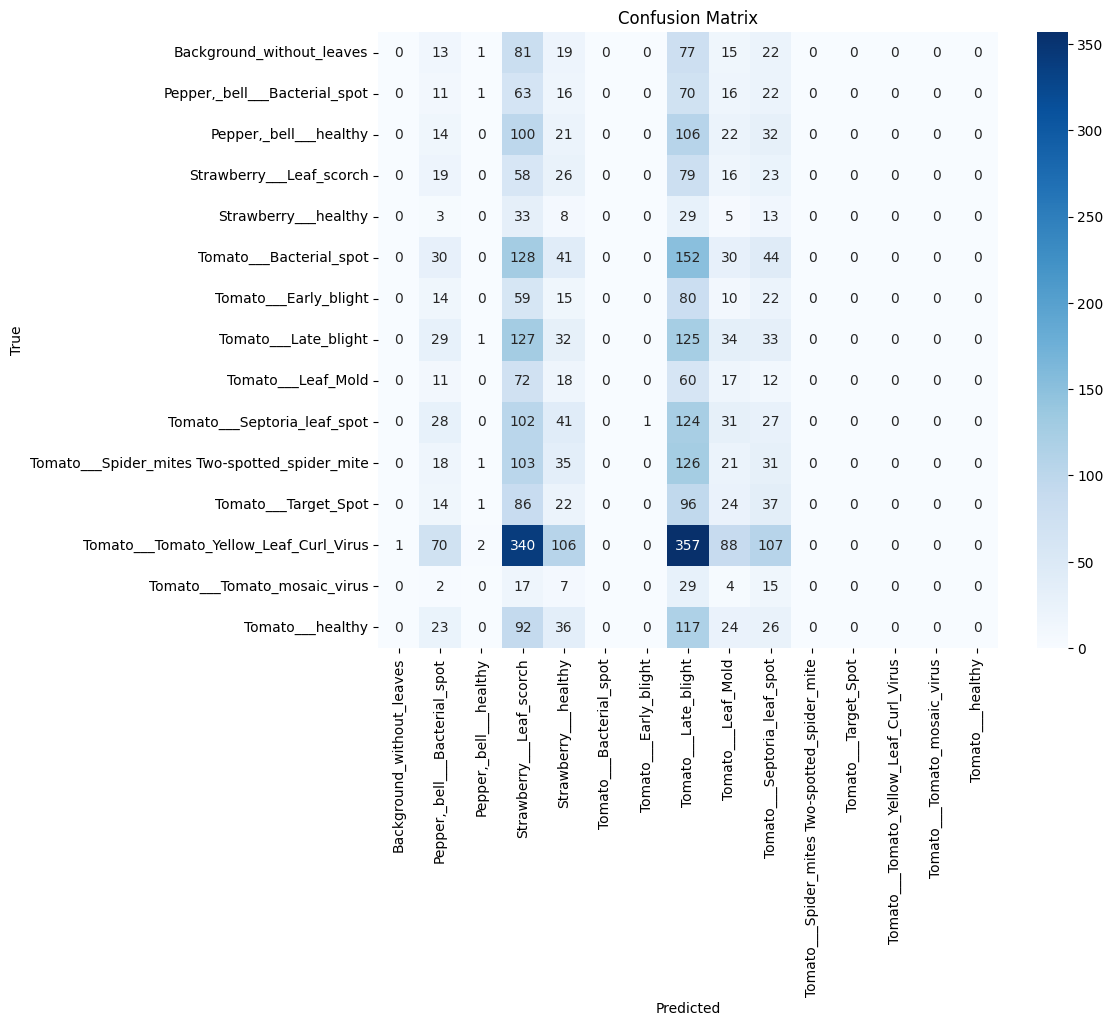

                                               precision    recall  f1-score   support

                    Background_without_leaves       0.00      0.00      0.00       228
                Pepper,_bell___Bacterial_spot       0.04      0.06      0.04       199
                       Pepper,_bell___healthy       0.00      0.00      0.00       295
                     Strawberry___Leaf_scorch       0.04      0.26      0.07       221
                         Strawberry___healthy       0.02      0.09      0.03        91
                      Tomato___Bacterial_spot       0.00      0.00      0.00       425
                        Tomato___Early_blight       0.00      0.00      0.00       200
                         Tomato___Late_blight       0.08      0.33      0.12       381
                           Tomato___Leaf_Mold       0.05      0.09      0.06       190
                  Tomato___Septoria_leaf_spot       0.06      0.08      0.07       354
Tomato___Spider_mites Two-spotted_spider_m

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels
val.reset()
y_true = val.classes

# Predict
y_pred_prob = model.predict(val, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Class labels
labels = list(train.class_indices.keys())

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=labels))

In [ ]:
his = model.fit(train , steps_per_epoch= 16,
                          epochs= 50,
                          verbose= 1,
                          validation_data= val ,
                          validation_steps= 16 )

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 114s 7s/step - accuracy: 0.1094 - loss: 50.0450 - val_accuracy: 0.1777 - val_loss: 2.6847
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 141s 9s/step - accuracy: 0.1738 - loss: 2.6493 - val_accuracy: 0.1738 - val_loss: 2.6875
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 108s 7s/step - accuracy: 0.1641 - loss: 2.7010 - val_accuracy: 0.2637 - val_loss: 2.6906
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step - accuracy: 0.1836 - loss: 2.6899 - val_accuracy: 0.1934 - val_loss: 2.6552
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 112s 7s/step - accuracy: 0.1934 - loss: 2.6720 - val_accuracy: 0.2207 - val_loss: 2.6635
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 104s 7s/step - accuracy: 0.2363 - loss: 2.6433 - val_accuracy: 0.2246 - val_loss: 2.6363
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step - accuracy: 0.2227 - loss: 2.5642 - val_accuracy: 0.2188 - val_loss: 2.5182
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 141s 9s/step - accuracy: 0.2637 - loss: 2.4620 - val_accuracy: 0.2559 - 

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


16/16 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.2917 - loss: 2.3155 - val_accuracy: 0.2676 - val_loss: 2.2739
Epoch 29/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 140s 9s/step - accuracy: 0.2617 - loss: 2.2705 - val_accuracy: 0.2891 - val_loss: 2.1449
Epoch 30/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step - accuracy: 0.2852 - loss: 2.2659 - val_accuracy: 0.3184 - val_loss: 2.0492
Epoch 31/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 142s 9s/step - accuracy: 0.2869 - loss: 2.1894 - val_accuracy: 0.2441 - val_loss: 2.2384
Epoch 32/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 104s 7s/step - accuracy: 0.3223 - loss: 2.1715 - val_accuracy: 0.3125 - val_loss: 2.0946
Epoch 33/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 142s 9s/step - accuracy: 0.2988 - loss: 2.1626 - val_accuracy: 0.3320 - val_loss: 2.0293
Epoch 34/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 106s 7s/step - accuracy: 0.3359 - loss: 2.1695 - val_accuracy: 0.3203 - val_loss: 2.1137
Epoch 35/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 141s 9s/step - accuracy: 0.2949 - loss: 2.1639 - val_accuracy: 0.3848 - val_lo

In [ ]:
h = his.history
h.keys()

plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.show()

plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()

NameError: name 'his' is not defined